In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
'''
0: x
1: x*
2: x* с нормой x
3: x с нормой x^*

'''

'\n0: x\n1: x*\n2: x* с нормой x\n3: x с нормой x^*\n\n'

In [3]:
# !pip install accelerate torch torchvision diffusers transformers


In [4]:
from IPython.display import display
import types
import torch
from functools import partial
from diffusers import FluxPipeline
from models.flux_schnell import encode_prompt, forward_modulation_guidance
from pathlib import Path

# Import a model
pipe = FluxPipeline.from_pretrained("black-forest-labs/FLUX.1-schnell", torch_dtype=torch.bfloat16).to('cuda')

/opt/miniforge3/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniforge3/lib/python3.14/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 13.42it/s]


In [5]:
# Define the hyperparametrs: 
# 1. Prompts: Generation prompt, positive and negative prompts
# 2. Modulation guidance strength (w)
# 3. Guidance start layer
prompt = 'A wolf on a plain background'
prompt_positive = "Ultra-detailed, photorealistic, cinematic"
prompt_negative = "Low-res, flat, cartoonish"

w = 3
start_layer = 5

# Get pooled CLIP embeddings
clip_positive = encode_prompt(pipe=pipe, prompt=prompt_positive)
clip_negative = encode_prompt(pipe=pipe, prompt=prompt_negative)

forward_logger = []

# Change forward of the pipe using the prompts and guidance weight
forward_modulation_guidance_partial = partial(forward_modulation_guidance, 
                                      pooled_projections_1=clip_positive, 
                                      pooled_projections_0=clip_negative,
                                      w=w, start_layer=start_layer, 
                                      log=forward_logger)
pipe.transformer.forward = types.MethodType(forward_modulation_guidance_partial, pipe.transformer)

In [6]:
# Run generation
seed = 0
images = pipe([prompt] * 4,
              guidance_scale=0.0,
              num_inference_steps=4,
              max_sequence_length=256,
              generator=[torch.Generator("cpu").manual_seed(seed) for _ in range(4)],
              output_type='pil').images

100%|██████████| 4/4 [00:08<00:00,  2.10s/it]


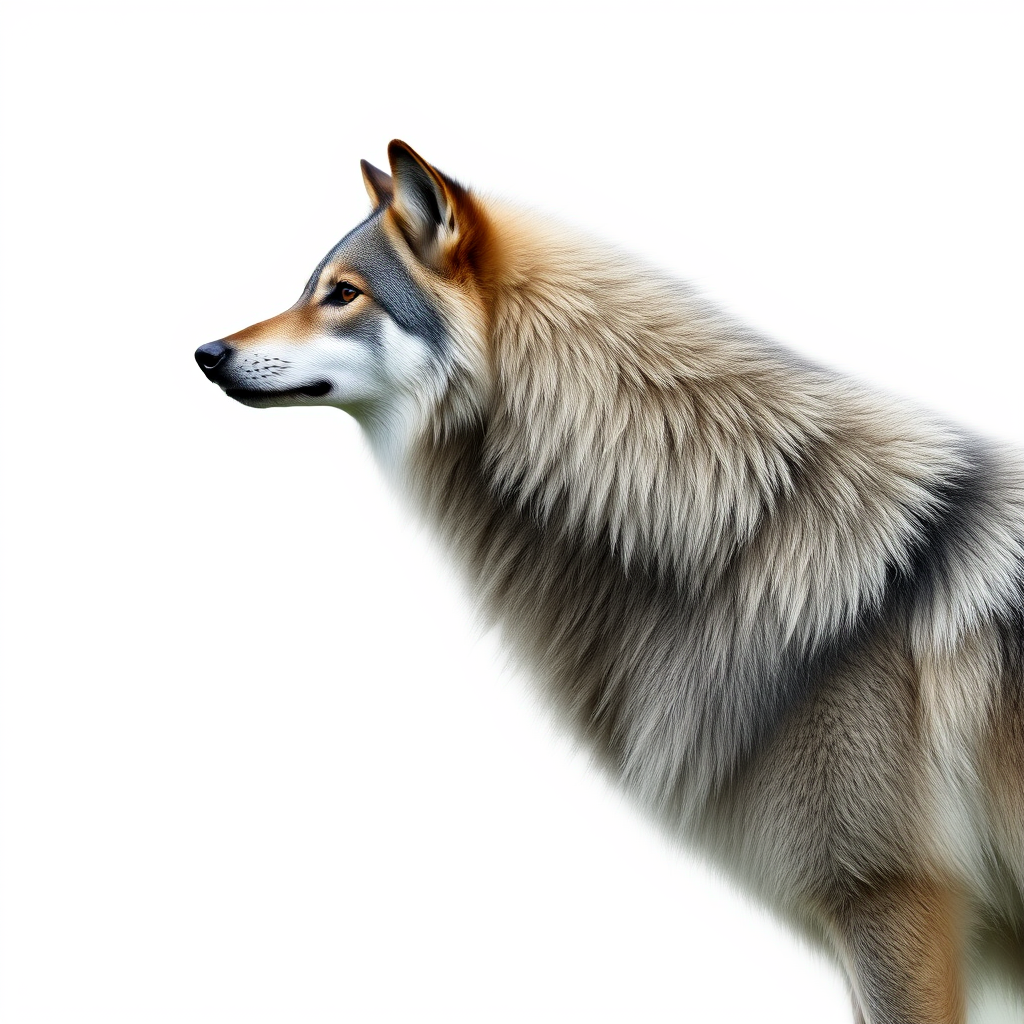

In [7]:
display(images[0])

In [16]:
from pprint import pprint


print(len(forward_logger))
print()
pprint(forward_logger[0])
print()
pprint(forward_logger[2])
print()
pprint(forward_logger[-1])


4

{'norm(temb_mix,dim=-1)': tensor([263.4548, 247.0098, 263.9927, 246.5807]),
 'p=0:angle(x*,x+-x-)': tensor(2.4420),
 'p=0:angle(x,x+-x-)': tensor(2.4934),
 'p=0:||x+-x-||': tensor(21.0401),
 'temb_mix': tensor([[-0.0723, -0.0245,  0.0374,  ...,  0.0275,  0.0079, -0.0835],
        [-0.1001, -0.0752, -0.0095,  ...,  0.1650,  0.0109, -0.0469],
        [-0.1069, -0.0806, -0.0102,  ...,  0.1758,  0.0117, -0.0500],
        [-0.0679, -0.0229,  0.0352,  ...,  0.0256,  0.0074, -0.0781]]),
 'timestep': tensor([1000., 1000., 1000., 1000.], dtype=torch.bfloat16)}

{'norm(temb_mix,dim=-1)': tensor([221.8523, 205.3074, 222.3806, 204.8576]),
 'p=0:angle(x*,x+-x-)': tensor(2.4510),
 'p=0:angle(x,x+-x-)': tensor(2.5111),
 'p=0:||x+-x-||': tensor(20.9410),
 'temb_mix': tensor([[-0.0244, -0.0002,  0.0200,  ...,  0.0181,  0.0008, -0.0549],
        [-0.0518, -0.0510, -0.0269,  ...,  0.1562,  0.0038, -0.0176],
        [-0.0562, -0.0552, -0.0292,  ...,  0.1699,  0.0042, -0.0190],
        [-0.0226, -0.0002

In [8]:

# main_dir = Path('generations')
# test_dir = main_dir / 'test'
# test_dir.mkdir(parents=True, exist_ok=True)

# for i, img in enumerate(images):
#     img.save(test_dir / f"image_{i}.png")